# 04 — Đánh giá mô hình PhoBERT ABSA

Notebook này đánh giá **model tốt nhất đã lưu**

### Quy trình

1. Đọc tập `test` từ dataset ABSA
2. Dùng đúng tokenizer và checkpoint đã huấn luyện
3. Thu thập `presence_probs` và `polarity_probs`
4. Giải mã bằng threshold đã lưu trong `best_model`
5. Gọi các hàm trong `src/evaluation/sentiment_metrics.py`
6. Hiển thị KPI, bảng theo aspect, confusion matrix và calibration
7. Xuất JSON, CSV, PNG và báo cáo HTML

> **Quan trọng:** Không tune threshold trên tập test. Notebook chỉ đọc threshold đã được tune trên tập dev (validation)

In [1]:
from __future__ import annotations

import html
import json
import math
import os
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from IPython.display import HTML, Markdown, display
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message=r".*You are using a model of type.*")
warnings.filterwarnings("ignore", message=r".*You are sending unauthenticated requests.*")

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")


def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc có src/ và notebooks/."""
    current = start.resolve()
    if current.is_file():
        current = current.parent

    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError(
        "Không tìm thấy project root có thư mục src/. "
        "Hãy mở notebook từ project Food_Review_NLP."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.modeling.evaluator import decode_predictions, load_thresholds
from src.modeling.model import (
    get_aspect_names,
    get_device,
    get_polarity_names,
    load_model_from_checkpoint,
)
from src.evaluation.sentiment_metrics import (
    compute_absa_metrics,
    compute_calibration_metrics,
    format_metrics_summary,
    save_metrics_report,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"Device khả dụng: {get_device()}")

Project root: C:\Users\ADMIN\Downloads\Food_Review_NLP
PyTorch: 2.12.1+cu130
Device khả dụng: cuda


In [2]:
# Giao diện hiển thị trong notebook
display(HTML("""
<style>
:root {
    --absa-bg: #f6f8fc;
    --absa-panel: #ffffff;
    --absa-text: #172033;
    --absa-muted: #667085;
    --absa-line: #e4e7ec;
    --absa-accent: #315efb;
}
.absa-hero {
    background: linear-gradient(135deg, #172554, #315efb);
    color: white;
    border-radius: 18px;
    padding: 26px 30px;
    margin: 8px 0 20px;
    box-shadow: 0 15px 35px rgba(35, 55, 120, .18);
}
.absa-hero h2 { margin: 0 0 7px; font-size: 27px; }
.absa-hero p { margin: 0; opacity: .86; }
.absa-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(165px, 1fr));
    gap: 12px;
    margin: 14px 0 20px;
}
.absa-card {
    background: var(--absa-panel);
    border: 1px solid var(--absa-line);
    border-radius: 14px;
    padding: 16px;
    box-shadow: 0 6px 20px rgba(16, 24, 40, .05);
}
.absa-label { color: var(--absa-muted); font-size: 12px; }
.absa-value { color: var(--absa-text); font-size: 25px; font-weight: 750; margin-top: 6px; }
.absa-note { color: var(--absa-muted); font-size: 11px; margin-top: 4px; }
.absa-good { border-top: 4px solid #16a34a; }
.absa-main { border-top: 4px solid var(--absa-accent); }
.absa-warn { border-top: 4px solid #f59e0b; }
.absa-panel {
    background: white;
    border: 1px solid var(--absa-line);
    border-radius: 14px;
    padding: 16px 18px;
    margin: 12px 0;
}
</style>
<div class="absa-hero">
  <h2>Đánh giá PhoBERT ABSA</h2>
  <p>Aspect detection · Aspect + Polarity · Per-aspect analysis · Calibration</p>
</div>
"""))

## 1. Cấu hình đánh giá

In [3]:
# =========================
# CẤU HÌNH CÓ THỂ THAY ĐỔI
# =========================

CHECKPOINT_DIR = PROJECT_ROOT / "models" / "saved_models" / "best_model"

# Để None, notebook sẽ tự tìm dataset phù hợp.
DATA_PATH: Optional[Path] = None

# Chỉ dùng split human test để báo cáo cuối cùng.
EVALUATION_SPLIT = "test"

BATCH_SIZE = int(getattr(config, "BATCH_SIZE", 16))
MAX_LEN = int(getattr(config, "MAX_LEN", 192))
NUM_WORKERS = 0  # Windows/Jupyter ổn định nhất với 0
PIN_MEMORY = torch.cuda.is_available()

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "metrics" / "04_evaluation"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "04_evaluation"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint : {CHECKPOINT_DIR}")
print(f"Split      : {EVALUATION_SPLIT}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Max length : {MAX_LEN}")
print(f"Output     : {OUTPUT_DIR}")

Checkpoint : C:\Users\ADMIN\Downloads\Food_Review_NLP\models\saved_models\best_model
Split      : test
Batch size : 16
Max length : 192
Output     : C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation


## 2. Đọc và chuẩn bị tập test

In [4]:
def read_dataframe(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        last_error = None
        for encoding in ("utf-8-sig", "utf-8", "cp1258"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError as exc:
                last_error = exc
        raise last_error or ValueError(f"Không đọc được CSV: {path}")

    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)

    raise ValueError(f"Không hỗ trợ định dạng: {suffix}")


def locate_dataset(manual_path: Optional[Path] = None) -> Path:
    if manual_path is not None:
        path = manual_path if manual_path.is_absolute() else PROJECT_ROOT / manual_path
        if not path.exists():
            raise FileNotFoundError(path)
        return path.resolve()

    candidates = [
        PROJECT_ROOT / "data" / "processed" / "VLSP2018-ABSA-Restaurant.parquet",
        PROJECT_ROOT / "data" / "processed" / "phase2_human_absa.parquet",
        PROJECT_ROOT / "data" / "raw" / "VLSP2018-ABSA-Restaurant.csv",
        PROJECT_ROOT / "data" / "raw" / "VLSP2018-ABSA-Restaurant(2).csv",
        PROJECT_ROOT / "data" / "raw" / "VLSP2018-ABSA-Restaurant(3).csv",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    matches = []

    processed_dir = PROJECT_ROOT / "data" / "processed"
    raw_dir = PROJECT_ROOT / "data" / "raw"

    if processed_dir.exists():
        matches.extend(sorted(processed_dir.glob("*VLSP*")))

    if raw_dir.exists():
        matches.extend(sorted(raw_dir.glob("*VLSP*")))
    matches = [
        path for path in matches
        if path.suffix.lower() in {".csv", ".parquet", ".xlsx", ".xls"}
    ]

    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(
        "Không tìm thấy dataset ABSA. Hãy gán DATA_PATH ở cell cấu hình."
    )


def infer_text_column(df: pd.DataFrame) -> str:
    candidates = (
        "phobert_text",
        "processed_comments",
        "tokenized_text",
        "Review",
        "review",
        "Comment",
        "comment",
        "text",
    )
    for column in candidates:
        if column in df.columns:
            return column

    raise ValueError(
        f"Không tìm thấy cột review. Các cột hiện có: {list(df.columns)}"
    )


DATASET_PATH = locate_dataset(DATA_PATH)
raw_df = read_dataframe(DATASET_PATH)

aspect_names = get_aspect_names()
polarity_names = get_polarity_names()

missing_aspects = [name for name in aspect_names if name not in raw_df.columns]
if missing_aspects:
    raise ValueError(
        "Dataset không có đủ nhãn ABSA. Thiếu: "
        + ", ".join(missing_aspects)
    )

eval_df = raw_df.copy()

if EVALUATION_SPLIT and "type" in eval_df.columns:
    split_mask = (
        eval_df["type"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(EVALUATION_SPLIT.casefold())
    )
    if split_mask.any():
        eval_df = eval_df.loc[split_mask].copy()
    else:
        print(
            f"[CẢNH BÁO] Không có split '{EVALUATION_SPLIT}', "
            "đang dùng toàn bộ dataset."
        )

eval_df = eval_df.reset_index(drop=True)
text_col = infer_text_column(eval_df)

for aspect in aspect_names:
    eval_df[aspect] = pd.to_numeric(
        eval_df[aspect], errors="raise"
    ).astype(int)

invalid = {
    aspect: sorted(set(eval_df[aspect].unique()) - {0, 1, 2, 3})
    for aspect in aspect_names
}
invalid = {key: value for key, value in invalid.items() if value}
if invalid:
    raise ValueError(f"Phát hiện label không hợp lệ: {invalid}")

display(HTML(
    f"""
    <div class="absa-panel">
      <b>Dataset:</b> {html.escape(str(DATASET_PATH))}<br>
      <b>Split:</b> {html.escape(EVALUATION_SPLIT)}<br>
      <b>Số mẫu đánh giá:</b> {len(eval_df):,}<br>
      <b>Cột text ban đầu:</b> {html.escape(text_col)}<br>
      <b>Số aspect:</b> {len(aspect_names)}
    </div>
    """
))

display(eval_df.head(3))

,Review,AMBIENCE#GENERAL,DRINKS#PRICES,DRINKS#QUALITY,DRINKS#STYLE&OPTIONS,FOOD#PRICES,FOOD#QUALITY,FOOD#STYLE&OPTIONS,LOCATION#GENERAL,RESTAURANT#GENERAL,RESTAURANT#MISCELLANEOUS,RESTAURANT#PRICES,SERVICE#GENERAL,type,dataset,phobert_text,aspect_sentiment
0,Đây là 1 trong những quán mà mình thích vì vị ...,0,3,1,3,0,0,0,0,1,0,0,0,test,VLSP2018-ABSA-Restaurant,Đây là 1 trong những quán mà mình thích vì vị ...,"{""DRINKS#PRICES"": 3, ""DRINKS#QUALITY"": 1, ""DRI..."
1,Bữa lướt facebook nhỏ bạn thấy có check-in ly ...,0,0,1,1,1,1,1,3,0,3,0,0,test,VLSP2018-ABSA-Restaurant,Bữa lướt facebook nhỏ bạn thấy có tính_tiền - ...,"{""DRINKS#QUALITY"": 1, ""DRINKS#STYLE&OPTIONS"": ..."
2,Nghe phông phanh về trà sữa có viên phô mai to...,1,1,1,1,0,0,1,0,1,0,0,0,test,VLSP2018-ABSA-Restaurant,Nghe phông phanh về trà_sữa có viên phô_mai to...,"{""AMBIENCE#GENERAL"": 1, ""DRINKS#PRICES"": 1, ""D..."


In [5]:
# Đảm bảo input dùng đúng định dạng PhoBERT.
# Nếu dataset đã có phobert_text thì không tiền xử lý lại.

if text_col == "phobert_text":
    model_text_col = text_col
else:
    from src.modeling.inference import preprocess_for_model

    model_text_col = "phobert_text"
    cache_path = OUTPUT_DIR / "evaluation_input_cache.parquet"

    if cache_path.exists():
        cached = pd.read_parquet(cache_path)
        if (
            len(cached) == len(eval_df)
            and model_text_col in cached.columns
        ):
            eval_df[model_text_col] = cached[model_text_col].fillna("").astype(str)
            print(f"Đã dùng cache tiền xử lý: {cache_path}")
        else:
            cache_path.unlink(missing_ok=True)

    if model_text_col not in eval_df.columns:
        processed_texts = []
        for text in tqdm(
            eval_df[text_col].fillna("").astype(str),
            desc="Tiền xử lý",
            unit="review",
            dynamic_ncols=True,
        ):
            processed_texts.append(preprocess_for_model(text))

        eval_df[model_text_col] = processed_texts
        eval_df[[text_col, model_text_col]].to_parquet(
            cache_path,
            index=False,
        )
        print(f"Đã lưu cache: {cache_path}")

empty_count = int(
    eval_df[model_text_col].fillna("").astype(str).str.strip().eq("").sum()
)
if empty_count:
    raise ValueError(
        f"Có {empty_count} review rỗng sau tiền xử lý."
    )

print(f"Cột đưa vào model: {model_text_col}")
display(
    eval_df[[text_col, model_text_col]].head(5)
    if text_col != model_text_col
    else eval_df[[model_text_col]].head(5)
)

Cột đưa vào model: phobert_text


,phobert_text
0,Đây là 1 trong những quán mà mình thích vì vị ...
1,Bữa lướt facebook nhỏ bạn thấy có tính_tiền - ...
2,Nghe phông phanh về trà_sữa có viên phô_mai to...
3,"Lại là mình tín_đồ nghiện trà_sữa đây , thấy q..."
4,không_gian quán sang_trọng khá đẹp mang phong_...


## 3. Load checkpoint và chạy inference

In [6]:
class EvaluationDataset(Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len: int,
    ):
        self.texts = list(texts)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = int(max_len)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            str(self.texts[index]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {
            key: value.squeeze(0)
            for key, value in encoded.items()
        }
        item["labels"] = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )
        return item


if not CHECKPOINT_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint: {CHECKPOINT_DIR}"
    )

tokenizer, model = load_model_from_checkpoint(str(CHECKPOINT_DIR))
device = get_device()
model.to(device)
model.eval()

thresholds = load_thresholds(
    str(CHECKPOINT_DIR),
    default=float(getattr(config, "DEFAULT_ABSA_THRESHOLD", 0.55)),
)

dataset = EvaluationDataset(
    texts=eval_df[model_text_col].fillna("").astype(str).tolist(),
    labels=eval_df[aspect_names].astype(int).to_numpy(),
    tokenizer=tokenizer,
    max_len=MAX_LEN,
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

display(HTML(
    f"""
    <div class="absa-panel">
      <b>Model:</b> {html.escape(str(CHECKPOINT_DIR))}<br>
      <b>Device:</b> {html.escape(str(device))}<br>
      <b>Số batch:</b> {len(dataloader):,}<br>
      <b>Threshold:</b> {html.escape(str([round(x, 3) for x in thresholds]))}
    </div>
    """
))

In [7]:
@torch.inference_mode()
def collect_outputs_with_progress(
    model,
    dataloader,
    device,
) -> dict[str, Any]:
    all_presence = []
    all_polarity = []
    all_labels = []
    total_loss = 0.0
    loss_batches = 0

    started_at = time.perf_counter()

    progress = tqdm(
        dataloader,
        desc="Đánh giá model",
        unit="batch",
        dynamic_ncols=True,
        smoothing=0.08,
    )

    for batch in progress:
        batch = {
            key: value.to(device, non_blocking=True)
            for key, value in batch.items()
        }

        outputs = model(**batch)

        if outputs.loss is not None:
            total_loss += float(outputs.loss.item())
            loss_batches += 1

        presence = torch.sigmoid(
            outputs.presence_logits
        ).cpu().numpy()
        polarity = torch.softmax(
            outputs.polarity_logits,
            dim=-1,
        ).cpu().numpy()
        labels = batch["labels"].cpu().numpy()

        all_presence.append(presence)
        all_polarity.append(polarity)
        all_labels.append(labels)

        progress.set_postfix(
            loss=(
                f"{total_loss / loss_batches:.4f}"
                if loss_batches
                else "N/A"
            )
        )

    elapsed = time.perf_counter() - started_at

    return {
        "presence_probs": np.concatenate(all_presence, axis=0),
        "polarity_probs": np.concatenate(all_polarity, axis=0),
        "y_true": np.concatenate(all_labels, axis=0),
        "loss": (
            total_loss / loss_batches
            if loss_batches
            else None
        ),
        "elapsed_seconds": elapsed,
        "reviews_per_second": (
            len(dataset) / elapsed if elapsed > 0 else None
        ),
    }


collected = collect_outputs_with_progress(
    model,
    dataloader,
    device,
)

presence_probs = collected["presence_probs"]
polarity_probs = collected["polarity_probs"]
y_true = collected["y_true"]

y_pred = decode_predictions(
    presence_probs,
    polarity_probs,
    thresholds=thresholds,
)

print("Shapes:")
print("  y_true        :", y_true.shape)
print("  y_pred        :", y_pred.shape)
print("  presence_probs:", presence_probs.shape)
print("  polarity_probs:", polarity_probs.shape)
print(
    f"Tốc độ: {collected['reviews_per_second']:.2f} review/giây"
)

Đánh giá model:   0%|          | 0/32 [00:00<?, ?batch/s]

Shapes:
  y_true        : (500, 12)
  y_pred        : (500, 12)
  presence_probs: (500, 12)
  polarity_probs: (500, 12, 3)
Tốc độ: 181.26 review/giây


## 4. Tính metric bằng `sentiment_metrics.py`

In [8]:
metrics = compute_absa_metrics(
    y_true,
    y_pred,
    aspect_names=aspect_names,
    label_names=polarity_names,
    include_details=True,
)

calibration = compute_calibration_metrics(
    y_true,
    presence_probs=presence_probs,
    polarity_probs=polarity_probs,
    thresholds=thresholds,
    n_bins=15,
)

metrics["evaluation_loss"] = collected["loss"]
metrics["performance"] = {
    "elapsed_seconds": collected["elapsed_seconds"],
    "reviews_per_second": collected["reviews_per_second"],
}
metrics["calibration"] = calibration

saved_metric_files = save_metrics_report(
    metrics,
    OUTPUT_DIR,
    prefix="human_test_absa",
)

print(format_metrics_summary(metrics))
print("Đã lưu metric:")
for name, path in saved_metric_files.items():
    print(f"  {name}: {path}")

Aspect detection P/R/F1=0.6245/0.8462/0.7186 | Aspect+Polarity P/R/F1=0.5232/0.7090/0.6021 | Macro-F1=0.5667 | Exact row=0.0300
Đã lưu metric:
  json: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_absa.json
  per_aspect_csv: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_absa_per_aspect.csv
  per_label_csv: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_absa_per_label.csv
  confusion_matrix_csv: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_absa_confusion_matrix.csv


In [9]:
def metric_card(
    title: str,
    value: Any,
    note: str = "",
    card_class: str = "absa-main",
    percent: bool = False,
) -> str:
    if value is None:
        shown = "N/A"
    else:
        number = float(value)
        shown = (
            f"{number * 100:.2f}%"
            if percent
            else f"{number:.4f}"
        )

    return f"""
    <div class="absa-card {card_class}">
      <div class="absa-label">{html.escape(title)}</div>
      <div class="absa-value">{html.escape(shown)}</div>
      <div class="absa-note">{html.escape(note)}</div>
    </div>
    """


presence_cal = calibration.get("presence", {})
polarity_cal = calibration.get(
    "polarity_on_gold_aspects",
    {},
)

cards = "".join([
    metric_card(
        "Aspect Detection F1",
        metrics["aspect_f1"],
        "Có phát hiện đúng aspect hay không",
        "absa-good",
    ),
    metric_card(
        "Aspect + Polarity F1",
        metrics["polarity_f1"],
        "Metric end-to-end quan trọng nhất",
        "absa-good",
    ),
    metric_card(
        "Macro-F1 4 lớp",
        metrics["macro_f1"],
        "Cân bằng ảnh hưởng của các lớp",
    ),
    metric_card(
        "Label Accuracy",
        metrics["label_accuracy"],
        "Tính trên toàn bộ aspect slots",
    ),
    metric_card(
        "Exact Row Match",
        metrics["exact_row_match"],
        "Đúng toàn bộ aspect trong review",
    ),
    metric_card(
        "Presence ECE",
        presence_cal.get("ece"),
        "Càng gần 0 càng tốt",
        "absa-warn",
    ),
    metric_card(
        "Polarity ECE",
        polarity_cal.get("ece"),
        "Tính trên gold-mentioned aspects",
        "absa-warn",
    ),
    metric_card(
        "Evaluation Loss",
        collected["loss"],
        "Loss trung bình trên test",
    ),
])

display(HTML(f'<div class="absa-grid">{cards}</div>'))

## 5. Bảng phân tích chi tiết

In [10]:
per_aspect_rows = []

for aspect, values in metrics["per_aspect"].items():
    detection = values["aspect_detection"]
    joint = values["aspect_polarity_joint"]

    per_aspect_rows.append({
        "Aspect": aspect,
        "Support": values["support"],
        "Predicted": values["predicted"],
        "Prevalence": values["prevalence"],
        "Aspect Precision": detection["precision"],
        "Aspect Recall": detection["recall"],
        "Aspect F1": detection["f1"],
        "Joint Precision": joint["precision"],
        "Joint Recall": joint["recall"],
        "Joint F1": joint["f1"],
        "Macro-F1 4-class": values["macro_f1_4class"],
        "Gold Sentiment F1": (
            values["sentiment_macro_f1_on_gold_mentions"]
        ),
    })

per_aspect_df = (
    pd.DataFrame(per_aspect_rows)
    .sort_values("Joint F1", ascending=False)
    .reset_index(drop=True)
)

formatters = {
    column: "{:.4f}"
    for column in per_aspect_df.columns
    if column not in {"Aspect", "Support", "Predicted"}
}

display(
    per_aspect_df.style
    .format(formatters)
    .background_gradient(
        subset=[
            "Aspect F1",
            "Joint F1",
            "Macro-F1 4-class",
        ],
        cmap="YlGn",
        vmin=0,
        vmax=1,
    )
    .set_caption("Hiệu quả theo từng aspect")
    .set_properties(**{"text-align": "center"})
)

per_aspect_path = OUTPUT_DIR / "human_test_per_aspect_pretty.csv"
per_aspect_df.to_csv(
    per_aspect_path,
    index=False,
    encoding="utf-8-sig",
)
print(f"Đã lưu: {per_aspect_path}")

,Aspect,Support,Predicted,Prevalence,Aspect Precision,Aspect Recall,Aspect F1,Joint Precision,Joint Recall,Joint F1,Macro-F1 4-class,Gold Sentiment F1
0,FOOD#QUALITY,457,497,0.9140,0.9175,0.9978,0.9560,0.8290,0.9015,0.8637,0.4227,0.5683
1,FOOD#STYLE&OPTIONS,403,457,0.8060,0.8337,0.9454,0.8860,0.6915,0.7841,0.7349,0.4712,0.5754
2,FOOD#PRICES,331,413,0.6620,0.7845,0.9789,0.8710,0.6247,0.7795,0.6935,0.6458,0.7448
3,RESTAURANT#GENERAL,223,399,0.4460,0.4962,0.8879,0.6367,0.4762,0.8520,0.6109,0.3531,0.4684
4,AMBIENCE#GENERAL,255,261,0.5100,0.7395,0.7569,0.7481,0.5939,0.6078,0.6008,0.5611,0.5927
5,LOCATION#GENERAL,179,234,0.3580,0.6325,0.8268,0.7167,0.4786,0.6257,0.5424,0.5822,0.6551
6,SERVICE#GENERAL,175,243,0.3500,0.5185,0.7200,0.6029,0.4198,0.5829,0.4880,0.4450,0.4637
7,DRINKS#STYLE&OPTIONS,46,63,0.0920,0.3333,0.4565,0.3853,0.2857,0.3913,0.3303,0.3194,0.1967
8,DRINKS#QUALITY,71,93,0.1420,0.3441,0.4507,0.3902,0.2903,0.3803,0.3293,0.4021,0.3492
9,RESTAURANT#MISCELLANEOUS,130,319,0.2600,0.3041,0.7462,0.4321,0.2226,0.5462,0.3163,0.3263,0.4849


Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_per_aspect_pretty.csv


In [11]:
per_label_df = pd.DataFrame([
    {
        "Label": label,
        "ID": values["label_id"],
        "Precision": values["precision"],
        "Recall": values["recall"],
        "F1": values["f1"],
        "Support": values["support"],
        "Predicted": values["predicted"],
    }
    for label, values in metrics["per_label"].items()
])

display(
    per_label_df.style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
    })
    .background_gradient(
        subset=["Precision", "Recall", "F1"],
        cmap="YlGn",
        vmin=0,
        vmax=1,
    )
    .set_caption("Hiệu quả theo nhãn")
    .set_properties(**{"text-align": "center"})
)

,Label,ID,Precision,Recall,F1,Support,Predicted
0,none,0,0.8633,0.6562,0.7457,3581,2722
1,positive,1,0.5654,0.7903,0.6592,1669,2333
2,negative,2,0.3543,0.3899,0.3713,159,175
3,neutral,3,0.4338,0.5651,0.4908,591,770


## 6. Biểu đồ đánh giá

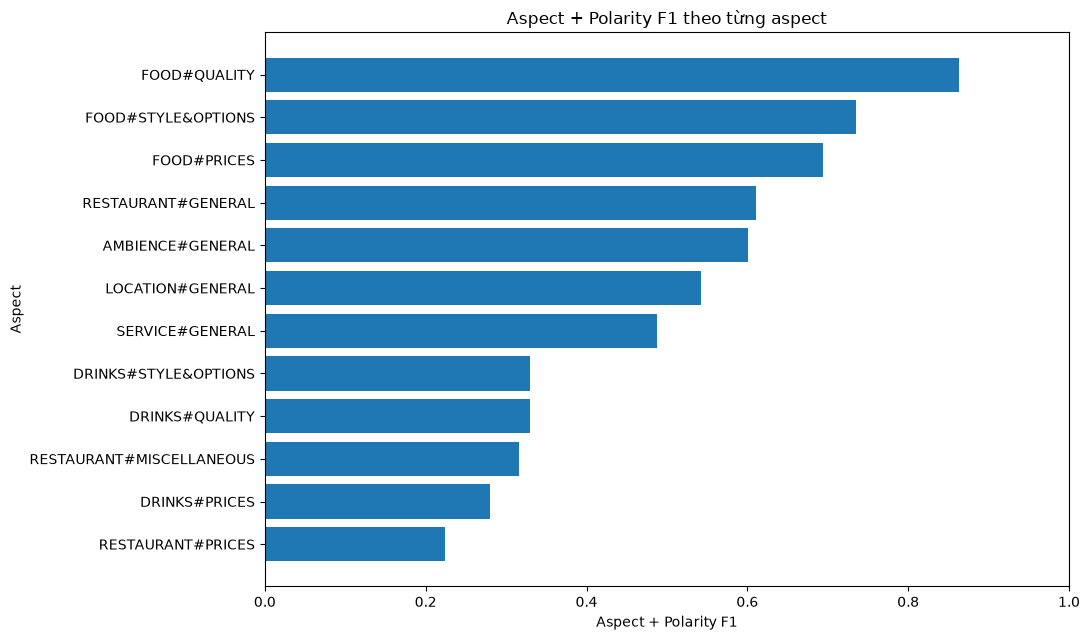

Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\joint_f1_by_aspect.png


In [12]:
# Biểu đồ 1: Joint F1 theo aspect
chart_df = per_aspect_df.sort_values("Joint F1", ascending=True)

plt.figure(figsize=(11, 6.5))
plt.barh(chart_df["Aspect"], chart_df["Joint F1"])
plt.xlim(0, 1)
plt.xlabel("Aspect + Polarity F1")
plt.ylabel("Aspect")
plt.title("Aspect + Polarity F1 theo từng aspect")
plt.tight_layout()

joint_f1_path = FIGURE_DIR / "joint_f1_by_aspect.png"
plt.savefig(joint_f1_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Đã lưu: {joint_f1_path}")

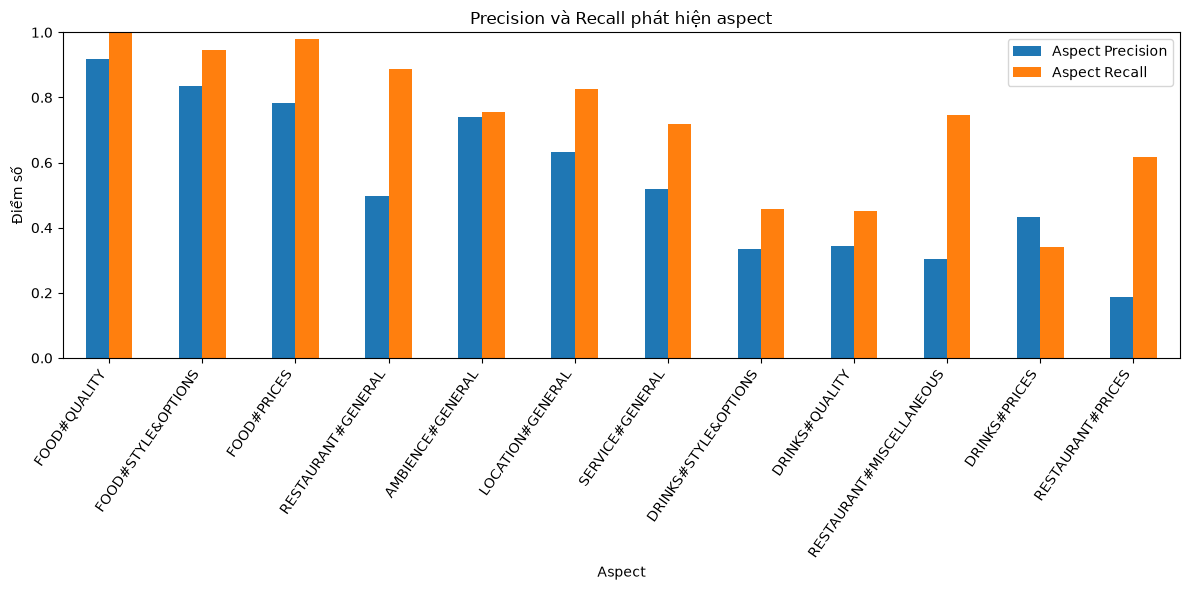

Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\aspect_precision_recall.png


In [13]:
# Biểu đồ 2: Precision và Recall aspect detection
plot_df = per_aspect_df.set_index("Aspect")[
    ["Aspect Precision", "Aspect Recall"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_ylim(0, 1)
ax.set_xlabel("Aspect")
ax.set_ylabel("Điểm số")
ax.set_title("Precision và Recall phát hiện aspect")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()

aspect_pr_path = FIGURE_DIR / "aspect_precision_recall.png"
plt.savefig(aspect_pr_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Đã lưu: {aspect_pr_path}")

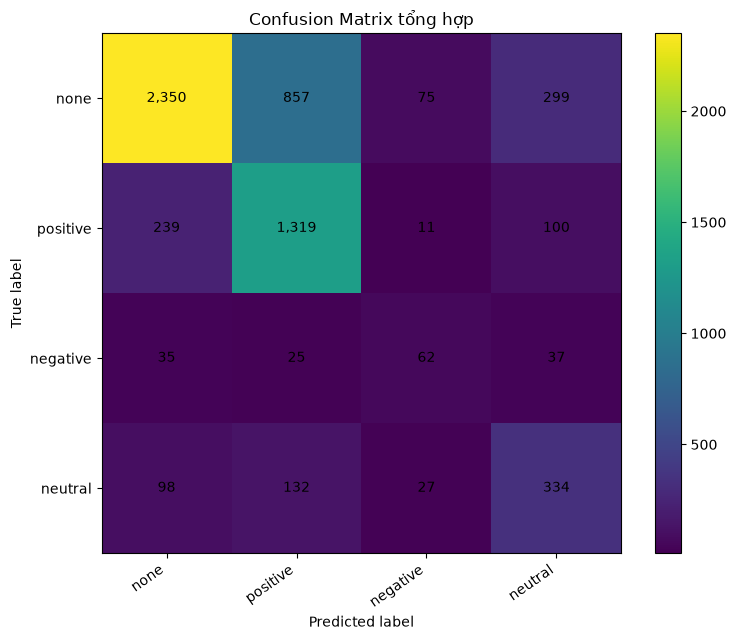

Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\confusion_matrix_4class.png


In [14]:
# Biểu đồ 3: Confusion matrix tổng hợp 4 nhãn
matrix = np.asarray(metrics["confusion_matrix"], dtype=int)

plt.figure(figsize=(7.5, 6.5))
plt.imshow(matrix)
plt.xticks(
    range(len(polarity_names)),
    polarity_names,
    rotation=35,
    ha="right",
)
plt.yticks(
    range(len(polarity_names)),
    polarity_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix tổng hợp")

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        plt.text(
            column,
            row,
            f"{matrix[row, column]:,}",
            ha="center",
            va="center",
        )

plt.tight_layout()

cm_path = FIGURE_DIR / "confusion_matrix_4class.png"
plt.savefig(cm_path, dpi=180, bbox_inches="tight")
plt.colorbar()
plt.show()

print(f"Đã lưu: {cm_path}")

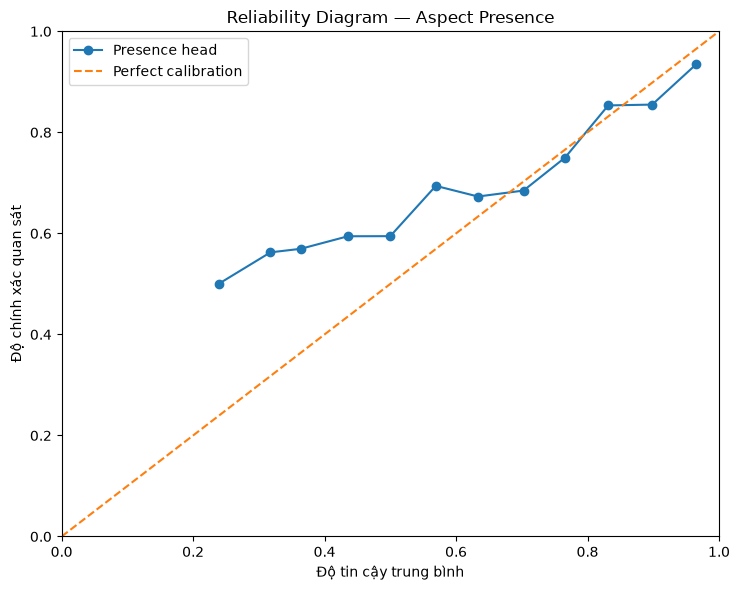

Presence ECE: 0.0609
Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\presence_reliability.png


In [15]:
def reliability_dataframe(
    confidences: np.ndarray,
    correctness: np.ndarray,
    n_bins: int = 15,
) -> pd.DataFrame:
    confidences = np.asarray(confidences, dtype=float).reshape(-1)
    correctness = np.asarray(correctness, dtype=float).reshape(-1)

    edges = np.linspace(0, 1, n_bins + 1)
    rows = []

    for index in range(n_bins):
        lower, upper = edges[index], edges[index + 1]
        mask = (
            (confidences >= lower) & (confidences <= upper)
            if index == 0
            else (confidences > lower) & (confidences <= upper)
        )

        if not mask.any():
            continue

        rows.append({
            "bin_center": (lower + upper) / 2,
            "mean_confidence": float(confidences[mask].mean()),
            "accuracy": float(correctness[mask].mean()),
            "count": int(mask.sum()),
        })

    return pd.DataFrame(rows)


threshold_array = np.asarray(thresholds).reshape(1, -1)
presence_pred = presence_probs >= threshold_array
presence_true = y_true != 0

presence_selected_conf = np.where(
    presence_pred,
    presence_probs,
    1.0 - presence_probs,
)
presence_correct = presence_pred == presence_true

presence_reliability = reliability_dataframe(
    presence_selected_conf,
    presence_correct,
)

plt.figure(figsize=(7.5, 6))
plt.plot(
    presence_reliability["mean_confidence"],
    presence_reliability["accuracy"],
    marker="o",
    label="Presence head",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Độ tin cậy trung bình")
plt.ylabel("Độ chính xác quan sát")
plt.title("Reliability Diagram — Aspect Presence")
plt.legend()
plt.tight_layout()

presence_cal_path = FIGURE_DIR / "presence_reliability.png"
plt.savefig(presence_cal_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Presence ECE: {presence_cal.get('ece', float('nan')):.4f}")
print(f"Đã lưu: {presence_cal_path}")

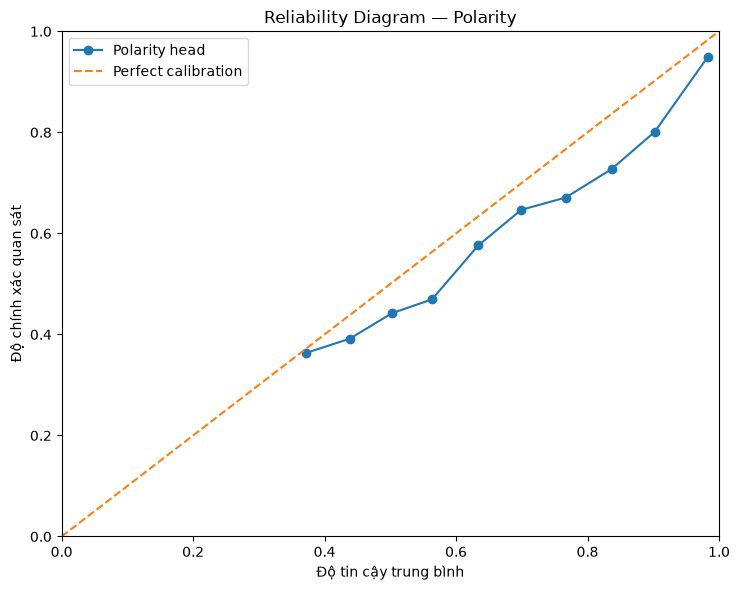

Polarity ECE: 0.0553
Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\polarity_reliability.png


In [16]:
# Biểu đồ 5: Reliability của polarity trên gold-mentioned aspects
gold_mask = y_true != 0
gold_probs = polarity_probs[gold_mask]
gold_targets = y_true[gold_mask] - 1

if len(gold_targets):
    polarity_prediction = np.argmax(gold_probs, axis=1)
    polarity_confidence = np.max(gold_probs, axis=1)
    polarity_correct = polarity_prediction == gold_targets

    polarity_reliability = reliability_dataframe(
        polarity_confidence,
        polarity_correct,
    )

    plt.figure(figsize=(7.5, 6))
    plt.plot(
        polarity_reliability["mean_confidence"],
        polarity_reliability["accuracy"],
        marker="o",
        label="Polarity head",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Độ tin cậy trung bình")
    plt.ylabel("Độ chính xác quan sát")
    plt.title("Reliability Diagram — Polarity")
    plt.legend()
    plt.tight_layout()

    polarity_cal_path = FIGURE_DIR / "polarity_reliability.png"
    plt.savefig(
        polarity_cal_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    print(
        f"Polarity ECE: "
        f"{polarity_cal.get('ece', float('nan')):.4f}"
    )
    print(f"Đã lưu: {polarity_cal_path}")
else:
    print("Không có gold-mentioned aspect để vẽ polarity reliability.")

## 7. Phân tích lỗi và lưu dự đoán

In [17]:
label_lookup = {
    index: name
    for index, name in enumerate(polarity_names)
}

prediction_rows = []
error_rows = []

for row_index in range(len(eval_df)):
    review_text = str(eval_df.iloc[row_index][text_col])
    processed_text = str(
        eval_df.iloc[row_index][model_text_col]
    )

    row_output = {
        "row_index": row_index,
        "review": review_text,
        "phobert_text": processed_text,
    }

    for aspect_index, aspect in enumerate(aspect_names):
        true_id = int(y_true[row_index, aspect_index])
        pred_id = int(y_pred[row_index, aspect_index])
        presence = float(
            presence_probs[row_index, aspect_index]
        )
        polarity_vector = polarity_probs[
            row_index,
            aspect_index,
        ]
        pred_polarity_conf = float(
            polarity_vector[pred_id - 1]
        ) if pred_id != 0 else float(
            np.max(polarity_vector)
        )

        row_output[f"{aspect}__true"] = label_lookup[true_id]
        row_output[f"{aspect}__pred"] = label_lookup[pred_id]
        row_output[
            f"{aspect}__presence_confidence"
        ] = presence
        row_output[
            f"{aspect}__polarity_confidence"
        ] = pred_polarity_conf

        if true_id == pred_id:
            continue

        if true_id != 0 and pred_id == 0:
            error_type = "missed_aspect"
            error_confidence = 1.0 - presence
        elif true_id == 0 and pred_id != 0:
            error_type = "false_positive_aspect"
            error_confidence = presence
        else:
            error_type = "wrong_polarity"
            error_confidence = pred_polarity_conf

        error_rows.append({
            "row_index": row_index,
            "review": review_text,
            "aspect": aspect,
            "error_type": error_type,
            "true_label": label_lookup[true_id],
            "predicted_label": label_lookup[pred_id],
            "presence_confidence": presence,
            "polarity_confidence": pred_polarity_conf,
            "effective_threshold": float(
                thresholds[aspect_index]
            ),
            "error_confidence": error_confidence,
        })

    prediction_rows.append(row_output)

predictions_df = pd.DataFrame(prediction_rows)
errors_df = (
    pd.DataFrame(error_rows)
    .sort_values(
        ["error_confidence", "row_index"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

predictions_path = OUTPUT_DIR / "human_test_predictions.csv"
errors_path = OUTPUT_DIR / "human_test_errors.csv"

predictions_df.to_csv(
    predictions_path,
    index=False,
    encoding="utf-8-sig",
)
errors_df.to_csv(
    errors_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"Predictions: {predictions_path}")
print(f"Errors     : {errors_path}")
print(f"Tổng lỗi aspect slots: {len(errors_df):,}")

if not errors_df.empty:
    display(
        errors_df.head(30).style
        .format({
            "presence_confidence": "{:.4f}",
            "polarity_confidence": "{:.4f}",
            "effective_threshold": "{:.4f}",
            "error_confidence": "{:.4f}",
        })
        .background_gradient(
            subset=["error_confidence"],
            cmap="OrRd",
            vmin=0,
            vmax=1,
        )
        .set_caption(
            "30 lỗi có độ tin cậy sai cao nhất"
        )
    )

Predictions: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_predictions.csv
Errors     : C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_errors.csv
Tổng lỗi aspect slots: 1,935


,row_index,review,aspect,error_type,true_label,predicted_label,presence_confidence,polarity_confidence,effective_threshold,error_confidence
0,295,"Quán này bán khá lâu năm ở Sài_Gòn rồi chắc nhiều bạn cũng biết , đặc_sản ở đây là món ốc_bươu_nhồi thịt chấm mắm_gừng , mấy nay trời mưa lạnh_tối mà đi lai_rai vài con ốc là hết sảy luôn vui_sướng_Quán thì hơi vắng khách , khi vào không_cần hỏi thì mặc_định nhân_viên cũng mang ra 10 con ốc trước nha ngoài_ra bây_giờ quán còn bán các món khác cũng chế_biến từ ốc_bươu nữa Ốc_bươu nhiều quá_chừng , ốc được hấp_ấm ấm chứ không_nóng quá lúc đem ra bàn thì hơi nguội_Ốc ăn chung với rau_răm và lá tía_tô Chấm mắm_gừng cay_cay Ốc_bươu nhồi thịt 7 k / con nha Hôm_nay mình đi thì thấy ốc cũng to chứ không_nhỏ đâu Khi ăn kéo 2 đầu cọng sả ra thì thịt ốc cũng ra luôn Thịt_ốc dồn chung với mộc giò sống và có thêm nấm mèo nữa , phần thịt ngon ăn dai_dai_sật sật thơm mùi sả_chấm với mắm_gừng nhưng được không_đậm_đà lắm Ăn_chung với lá tía_tô khá bắt_vị nè vui_sướng Món này mỗi người đi ăn_tầm 10 con mới lưng bụng được nên khá là hao mồi_nha Còn có các món khác từ ốc_bươu nữa giá_cả cũng khá bình_dân Coca - Cola 15 k hen",FOOD#PRICES,wrong_polarity,positive,neutral,0.8296,0.9984,0.6200,0.9984
1,336,"Đi trốn đời trong này thì tuyệt_luôn , đồ uống ngon , sáng_tạo , không_gian toàn kính là kính , rất phong_cách . không_gian tràn_ngập ánh_sáng và hoa nè . Các thức uống pha_chế ngon , lại để trong những ly tách chai lọ rất hợp_lý . Chesse ở đây cũng tốt / được , thơm_béo và ngon_miệng . Đồ ăn_no phải là không_thế mạnh của quán , cũng khá đắt nữa !",FOOD#QUALITY,wrong_polarity,neutral,positive,0.9650,0.9968,0.8000,0.9968
2,354,"Quán này nhà mình hay ra ăn , quán bán lâu_đời lắm rồi , ngày_trước ở Tôn_Thất_Thiệp nay dời về Lý_Chính_Thắng , hương_vị vẫn không_đổi_nha Hiện_tại quán chủ_yếu chỉ bán từ sáng đến trưa thôi , quán hơi khuất và nằm trên đường 1 chiều nên rất dễ bị bỏ_qua , mấy bạn nhớ để_ý kỹ bên tay_trái nhé Tôm_tươi và căng mọng ăn_ngọt thịt rất đã , đặc_biệt là món bánh tôm ăn kèm_giòn to giòn thơm_thơm , lòng được làm sạch kỹ nên ăn_không_bị đắng Một tô bình_thường là 38 k gồm có tôm thịt và lòng_phèo , mấy bạn muốn thêm cua là 50 k nhé , quán còn có cả xíu_quách nữa bạn nào ăn_khỏe thì gọi thêm nhé Hủ_tíu rất ngon , nhất_là hủ tíu khô , khác với những quán khác ở đây có nước sốt_trộn màu đỏ_cam đặc_trưng kèm theo sợi hủ tíu dai_dai_ăn rất lạ_miệng , dù nước lèo trong_vắt nhưng cực_kì đậm_đà_nha Cô_chú chủ quán rất là hiền luôn , chú bị lãng_tai rồi , dù khách ra vào tất_bật nhưng cô_chú vẫn vui_vẻ và điềm_tĩnh_Giá có cao hơn trước 1 chút , cô_chú nói là đồ_ăn ngoài chợ họ lên giá nên phải lên theo chứ mua đồ rẻ_tiền không_tươi bán mất mối hết , cơ_mà theo mình thấy giá như_vậy cực_kì hợp_lý , hủ_tíu rất nhiều , thịt cua tôm tươi_ngon và nhiều nên giá vậy cũng có không_gì phàn_nàn , các bạn nên ghé thử 1 lần để tự mình cảm_nhận nhé",FOOD#PRICES,wrong_polarity,positive,neutral,0.9259,0.9963,0.6200,0.9963
3,380,"Popeyes lại vừa ra mắ sản_phẩm nè mấy bạn , bữa đi ăn thử thấy ngon_ghê , thích hơn cái gà phủ phô_mai truyền_thống đợt trước Miếng gà nhìn đẫm_sốt nhìn hấp_dẫn hen mê_mẩn gói_kết_hợp này 159 k_nha , được khá nhiều thứ nè : có 2 miếng gà tiêu_tỏi , 3 miếng gà giòn không_xương , khoai_tây nghiền , rau_trộn trộn , 1 cái bánh_hamburger gà , 3 ly nước_ngọt miễn_phí refill nữa chứ gói_kết_hợp này ăn 3 người nha , nhưng chắc không_đủ_đô với bạn nào ăn mạnh gói_kết_hợp 86 k như truyền_thống thì có 2 miếng gà tiêu_tỏi , khoai_tây cajun , bánh_nướng mật_ong , 1 ly nước_ngọt hen Gà giòn không_xương ăn_nạc nhiều nên hơi dễ ngán , nhưng loại này thường các bé khoái hơn 2 cái đùi bé xinh_nè vui_sướng Ăn_ức là được nhiều thịt nhất_nha , tha_hồ mà cạp Thịt gà tươi_không_bở nghen , ít mỡ nữa , lớp da giòn_giòn , thấm_sốt tiêu_tỏi rất đậm_đà , món này chỉ hơi cay_cay thôi nên chắc ai cũng ăn được Đi ngay hôm t2 mà khá đông_đúc , chờ_đợi cũng hơi lâu_xíu . không_gian ở bên này thì sạch_đẹp , thoải_mái , 

,error_type,count,share
0,false_positive_aspect,1231,63.62%
1,missed_aspect,372,19.22%
2,wrong_polarity,332,17.16%


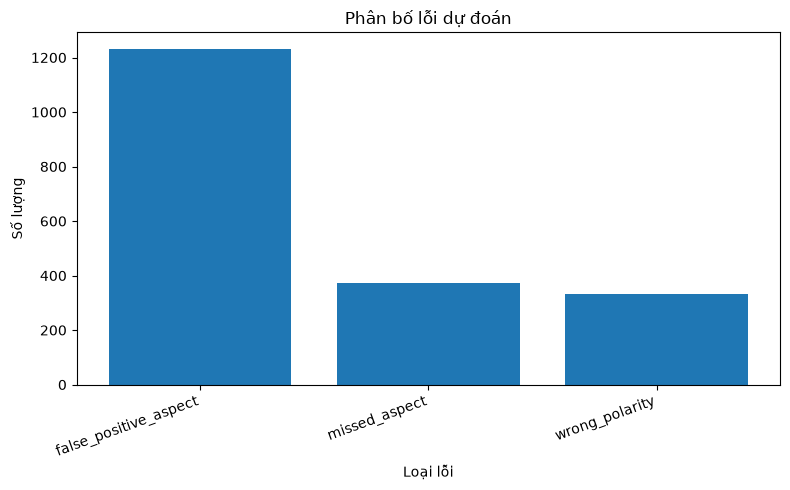

Đã lưu: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\figures\04_evaluation\error_type_distribution.png


In [18]:
# Thống kê loại lỗi
if errors_df.empty:
    error_type_df = pd.DataFrame(
        columns=["error_type", "count", "share"]
    )
else:
    error_type_df = (
        errors_df["error_type"]
        .value_counts()
        .rename_axis("error_type")
        .reset_index(name="count")
    )
    error_type_df["share"] = (
        error_type_df["count"] / len(errors_df)
    )

display(
    error_type_df.style.format({
        "share": "{:.2%}",
    }).set_caption("Phân bố loại lỗi")
)

if not error_type_df.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(
        error_type_df["error_type"],
        error_type_df["count"],
    )
    plt.xlabel("Loại lỗi")
    plt.ylabel("Số lượng")
    plt.title("Phân bố lỗi dự đoán")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    error_chart_path = FIGURE_DIR / "error_type_distribution.png"
    plt.savefig(
        error_chart_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    print(f"Đã lưu: {error_chart_path}")

## 8. Xuất báo cáo HTML

In [19]:
def dataframe_html(
    dataframe: pd.DataFrame,
    columns: list[str],
    max_rows: int = 30,
) -> str:
    selected = [
        column for column in columns
        if column in dataframe.columns
    ]
    if not selected or dataframe.empty:
        return "<p>Không có dữ liệu.</p>"

    return (
        dataframe[selected]
        .head(max_rows)
        .to_html(
            index=False,
            border=0,
            classes="report-table",
            float_format=lambda value: f"{value:.4f}",
        )
    )


report_cards = "".join([
    metric_card(
        "Aspect Detection F1",
        metrics["aspect_f1"],
        "Phát hiện aspect",
        "absa-good",
    ),
    metric_card(
        "Aspect + Polarity F1",
        metrics["polarity_f1"],
        "End-to-end",
        "absa-good",
    ),
    metric_card(
        "Macro-F1",
        metrics["macro_f1"],
        "4-class",
    ),
    metric_card(
        "Exact Row Match",
        metrics["exact_row_match"],
        "Đúng toàn bộ review",
    ),
    metric_card(
        "Presence ECE",
        presence_cal.get("ece"),
        "Càng thấp càng tốt",
        "absa-warn",
    ),
    metric_card(
        "Polarity ECE",
        polarity_cal.get("ece"),
        "Càng thấp càng tốt",
        "absa-warn",
    ),
])

aspect_table_html = dataframe_html(
    per_aspect_df,
    [
        "Aspect",
        "Support",
        "Aspect Precision",
        "Aspect Recall",
        "Aspect F1",
        "Joint Precision",
        "Joint Recall",
        "Joint F1",
        "Macro-F1 4-class",
    ],
)

label_table_html = dataframe_html(
    per_label_df,
    [
        "Label",
        "Precision",
        "Recall",
        "F1",
        "Support",
        "Predicted",
    ],
)

error_table_html = dataframe_html(
    errors_df,
    [
        "row_index",
        "aspect",
        "error_type",
        "true_label",
        "predicted_label",
        "presence_confidence",
        "polarity_confidence",
        "error_confidence",
    ],
    max_rows=40,
)

figure_names = [
    "joint_f1_by_aspect.png",
    "aspect_precision_recall.png",
    "confusion_matrix_4class.png",
    "presence_reliability.png",
    "polarity_reliability.png",
    "error_type_distribution.png",
]
figure_html = "".join(
    f'<div class="chart"><img src="{html.escape(str((FIGURE_DIR / name).resolve()))}"></div>'
    for name in figure_names
    if (FIGURE_DIR / name).exists()
)

report_html = f"""<!doctype html>
<html lang="vi">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>04 Evaluation — PhoBERT ABSA</title>
<style>
body {{
  margin: 0;
  background: #f5f7fb;
  color: #172033;
  font-family: Inter, Segoe UI, Arial, sans-serif;
}}
.container {{
  width: min(1180px, calc(100% - 32px));
  margin: 30px auto 60px;
}}
.hero {{
  padding: 30px;
  border-radius: 20px;
  color: white;
  background: linear-gradient(135deg, #172554, #315efb);
  box-shadow: 0 18px 45px rgba(37, 60, 130, .20);
}}
.hero h1 {{ margin: 0 0 8px; }}
.hero p {{ margin: 0; opacity: .85; }}
.absa-grid {{
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(165px, 1fr));
  gap: 12px;
  margin: 18px 0;
}}
.absa-card {{
  background: white;
  border: 1px solid #e4e7ec;
  border-radius: 14px;
  padding: 17px;
}}
.absa-label {{ color: #667085; font-size: 12px; }}
.absa-value {{ font-size: 25px; font-weight: 750; margin-top: 7px; }}
.absa-note {{ color: #667085; font-size: 11px; margin-top: 4px; }}
.absa-good {{ border-top: 4px solid #16a34a; }}
.absa-main {{ border-top: 4px solid #315efb; }}
.absa-warn {{ border-top: 4px solid #f59e0b; }}
.panel {{
  background: white;
  border: 1px solid #e4e7ec;
  border-radius: 16px;
  padding: 22px;
  margin-top: 18px;
  overflow-x: auto;
}}
.report-table {{
  width: 100%;
  border-collapse: collapse;
  font-size: 13px;
}}
.report-table th, .report-table td {{
  padding: 10px 12px;
  border-bottom: 1px solid #e4e7ec;
  text-align: left;
  white-space: nowrap;
}}
.report-table th {{ background: #f8fafc; }}
.charts {{
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(430px, 1fr));
  gap: 16px;
}}
.chart img {{ width: 100%; background: white; }}
</style>
</head>
<body>
<div class="container">
  <div class="hero">
    <h1>Đánh giá PhoBERT ABSA</h1>
    <p>{html.escape(str(DATASET_PATH))} · split={html.escape(EVALUATION_SPLIT)}</p>
  </div>

  <div class="absa-grid">{report_cards}</div>

  <section class="panel">
    <h2>Metric theo aspect</h2>
    {aspect_table_html}
  </section>

  <section class="panel">
    <h2>Metric theo nhãn</h2>
    {label_table_html}
  </section>

  <section class="panel">
    <h2>Các lỗi có confidence sai cao</h2>
    {error_table_html}
  </section>

  <section class="panel">
    <h2>Biểu đồ</h2>
    <div class="charts">{figure_html}</div>
  </section>
</div>
</body>
</html>
"""

report_path = OUTPUT_DIR / "human_test_evaluation_report.html"
report_path.write_text(report_html, encoding="utf-8")

print(f"Đã tạo báo cáo HTML: {report_path}")
display(HTML(
    f"""
    <div class="absa-panel">
      <b>Hoàn tất.</b><br>
      Báo cáo HTML: {html.escape(str(report_path))}<br>
      Metrics JSON: {html.escape(str(OUTPUT_DIR / "human_test_absa.json"))}<br>
      Predictions CSV: {html.escape(str(predictions_path))}<br>
      Errors CSV: {html.escape(str(errors_path))}
    </div>
    """
))

Đã tạo báo cáo HTML: C:\Users\ADMIN\Downloads\Food_Review_NLP\outputs\metrics\04_evaluation\human_test_evaluation_report.html


## Chú thích

- **Aspect Detection F1:** khả năng phát hiện aspect có xuất hiện hay không
- **Aspect + Polarity F1:** chỉ đúng khi model dự đoán đúng cả aspect và cảm xúc; đây là metric chính
- **Macro-F1:** cân bằng ảnh hưởng giữa các lớp, hữu ích khi dữ liệu mất cân bằng
- **Exact Row Match:** tỷ lệ review mà toàn bộ 12 aspect đều được dự đoán chính xác
- **ECE:** đo mức độ đáng tin của confidence; càng gần `0` càng tốt
- **Brier Score / NLL:** đánh giá chất lượng xác suất, không chỉ nhãn cuối cùng
- **Missed aspect:** nhãn thật có aspect nhưng model dự đoán `none`
- **False positive aspect:** nhãn thật là `none` nhưng model thêm aspect
- **Wrong polarity:** model phát hiện đúng aspect nhưng chọn sai cảm xúc